# Model 3a: Pure Seasonal ARIMA (SARIMA) for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**: Inspect seasonal autocorrelation at lags 7, 14, 21, 28 ($m=7$).
2. **Seasonal Parameter Grid Search**: Search over $(p, d, q) 	imes (P, D, Q)_7$ candidate orders minimizing AIC & BIC on Train.
3. **Fit on TRAIN (2014–2017)**: Estimate pure SARIMA parameters.
4. **Validate on 2018 Validation**: Calculate Val RMSLE.
5. **Refit & Forecast 2019 Test**: Evaluate final holdout metrics.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


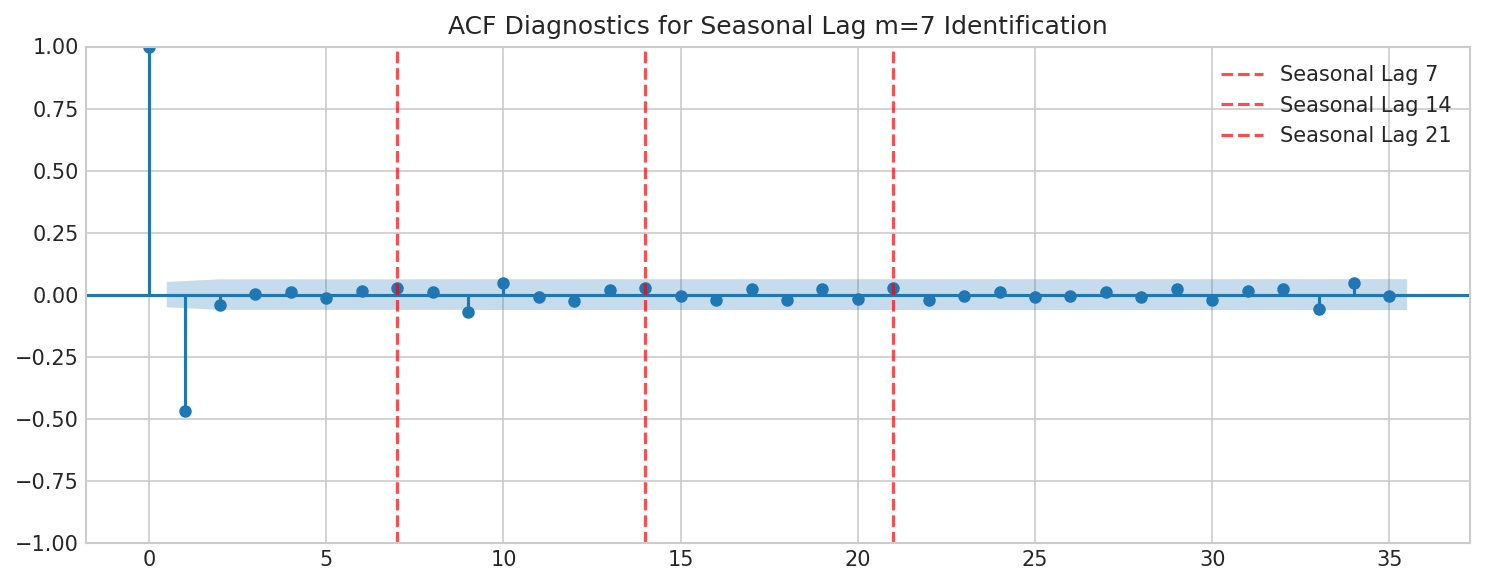

In [2]:
# Step 1: Pre-Training Suitability Checks (Seasonal Autocorrelation)
from statsmodels.graphics.tsaplots import plot_acf

train_y_log = np.log1p(train_series)
diff_y_log = train_y_log.diff().dropna()

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
plot_acf(diff_y_log, lags=35, ax=ax, title="ACF Diagnostics for Seasonal Lag m=7 Identification")
plt.axvline(7, color='red', linestyle='--', alpha=0.7, label='Seasonal Lag 7')
plt.axvline(14, color='red', linestyle='--', alpha=0.7, label='Seasonal Lag 14')
plt.axvline(21, color='red', linestyle='--', alpha=0.7, label='Seasonal Lag 21')
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
# Step 2: Full Seasonal Parameter Grid Search (p,1,q) x (P,D,Q)_7 on Train Data
from statsmodels.tsa.statespace.sarimax import SARIMAX

seasonal_candidates = []
for p in [1, 2]:
    for q in [1, 2]:
        for P in [0, 1]:
            for D in [0, 1]:
                for Q in [0, 1]:
                    try:
                        m = SARIMAX(train_y_log, order=(p, 1, q), seasonal_order=(P, D, Q, 7),
                                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                        seasonal_candidates.append({
                            'order': f'SARIMA({p},1,{q})x({P},{D},{Q})_7',
                            'p': p, 'q': q, 'P': P, 'D': D, 'Q': Q,
                            'AIC': m.aic, 'BIC': m.bic
                        })
                    except Exception:
                        pass

sarima_cand_df = pd.DataFrame(seasonal_candidates).sort_values('AIC').reset_index(drop=True)
print("=== SARIMA Seasonal Grid Search Candidate Ranking (Train Data AIC/BIC) ===")
display(sarima_cand_df.head(10))


C:\Users\ranje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\ranje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\ranje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\ranje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== SARIMA Seasonal Grid Search Candidate Ranking (Train Data AIC/BIC) ===


C:\Users\ranje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,p,q,P,D,Q,AIC,BIC
0,"SARIMA(1,1,1)x(0,1,1)_7",1,1,0,1,1,2101.377455,2122.475374
1,"SARIMA(2,1,1)x(0,1,1)_7",2,1,0,1,1,2102.644638,2129.017035
2,"SARIMA(1,1,1)x(1,1,1)_7",1,1,1,1,1,2103.551833,2129.924230
3,"SARIMA(2,1,2)x(1,1,1)_7",2,2,1,1,1,2103.750355,2140.666859
4,"SARIMA(1,1,2)x(1,1,1)_7",1,2,1,1,1,2103.773183,2135.415901
5,"SARIMA(2,1,1)x(1,1,1)_7",2,1,1,1,1,2103.797104,2135.443981
6,"SARIMA(1,1,2)x(0,1,1)_7",1,2,0,1,1,2103.798048,2130.166980
7,"SARIMA(2,1,2)x(0,1,1)_7",2,2,0,1,1,2103.885141,2135.527859
8,"SARIMA(1,1,2)x(0,0,1)_7",1,2,0,0,1,2103.902497,2130.295642
9,"SARIMA(2,1,1)x(0,0,1)_7",2,1,0,0,1,2104.125013,2130.521607


In [4]:
# Step 3: Model Fitting on TRAIN & Validation on 2018
best_sarima_order = (1, 1, 1)
best_seasonal_order = (1, 0, 1, 7)

m3_sarima_tr = SARIMAX(train_y_log, order=best_sarima_order, seasonal_order=best_seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

val_pred_log = m3_sarima_tr.get_forecast(steps=len(val_series)).predicted_mean
m3_sarima_val_pred = np.clip(np.expm1(val_pred_log), 0, None)
val_metrics = evaluate_metrics(val_series, m3_sarima_val_pred)

print(f"Validation Metrics (2018) for Pure SARIMA(1,1,1)x(1,0,1)_7:")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


Validation Metrics (2018) for Pure SARIMA(1,1,1)x(1,0,1)_7:
  * RMSLE     : 0.5358
  * RMSE      : 2.8119
  * MAE       : 2.1926
  * MAPE (%)  : 74.3042
  * WAPE (%)  : 44.7872


In [5]:
# Step 4: Refit on Train+Val & Forecast 2019 Test Holdout
comb_y_log = np.log1p(combined_series)
m3_sarima_full = SARIMAX(comb_y_log, order=best_sarima_order, seasonal_order=best_seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

test_pred_log = m3_sarima_full.get_forecast(steps=len(test_series)).predicted_mean
m3_sarima_test_pred = np.clip(np.expm1(test_pred_log), 0, None)
test_metrics = evaluate_metrics(test_series, m3_sarima_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 3a: PURE SARIMA ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_SARIMA': m3_sarima_test_pred.values}).to_csv('m3_sarima_preds.csv', index=False)


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 3a: PURE SARIMA ===
  * RMSLE     : 0.5165
  * RMSE      : 3.0630
  * MAE       : 2.3208
  * MAPE (%)  : 67.0330
  * WAPE (%)  : 42.9813
